In [3]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.xlsx to online_retail.xlsx


In [4]:
import pandas as pd

df = pd.read_excel("online_retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
import sqlite3

conn = sqlite3.connect("online_retail.db")
df.to_sql("online_retail", conn, if_exists="replace", index=False)

print("Database created successfully")

Database created successfully


In [6]:
query = """
SELECT *
FROM online_retail
LIMIT 5
"""

test_df = pd.read_sql(query, conn)
test_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
query = """
SELECT
strftime('%Y-%m', InvoiceDate) AS month,
SUM(Quantity * UnitPrice) AS revenue
FROM online_retail
GROUP BY month
ORDER BY month
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales.head()

,month,revenue
0,2010-12,748957.020
1,2011-01,560000.260
2,2011-02,498062.650
3,2011-03,683267.080
4,2011-04,493207.121


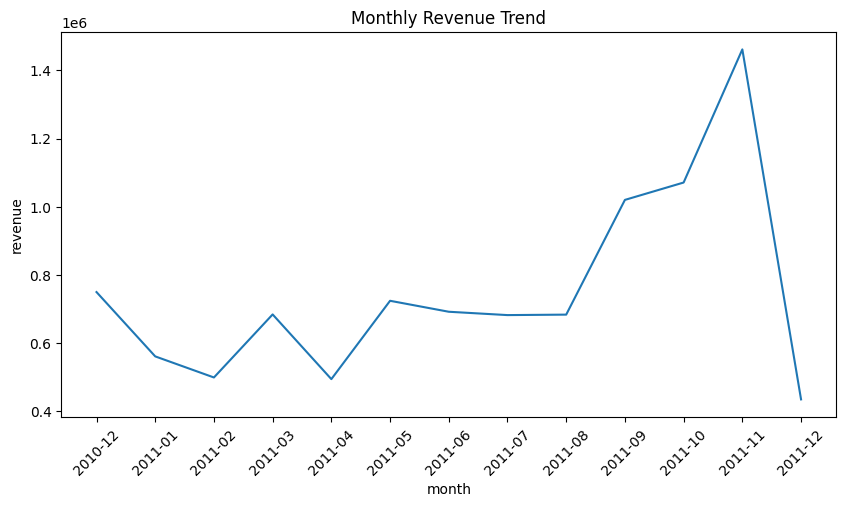

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="month", y="revenue")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

In [9]:
query = """
SELECT
Description,
SUM(Quantity) AS total_sold
FROM online_retail
GROUP BY Description
ORDER BY total_sold DESC
LIMIT 10
"""

top_products = pd.read_sql(query, conn)

top_products

,Description,total_sold
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
1,JUMBO BAG RED RETROSPOT,47363
2,ASSORTED COLOUR BIRD ORNAMENT,36381
3,POPCORN HOLDER,36334
4,PACK OF 72 RETROSPOT CAKE CASES,36039
5,WHITE HANGING HEART T-LIGHT HOLDER,35317
6,RABBIT NIGHT LIGHT,30680
7,MINI PAINT SET VINTAGE,26437
8,PACK OF 12 LONDON TISSUES,26315
9,PACK OF 60 PINK PAISLEY CAKE CASES,24753


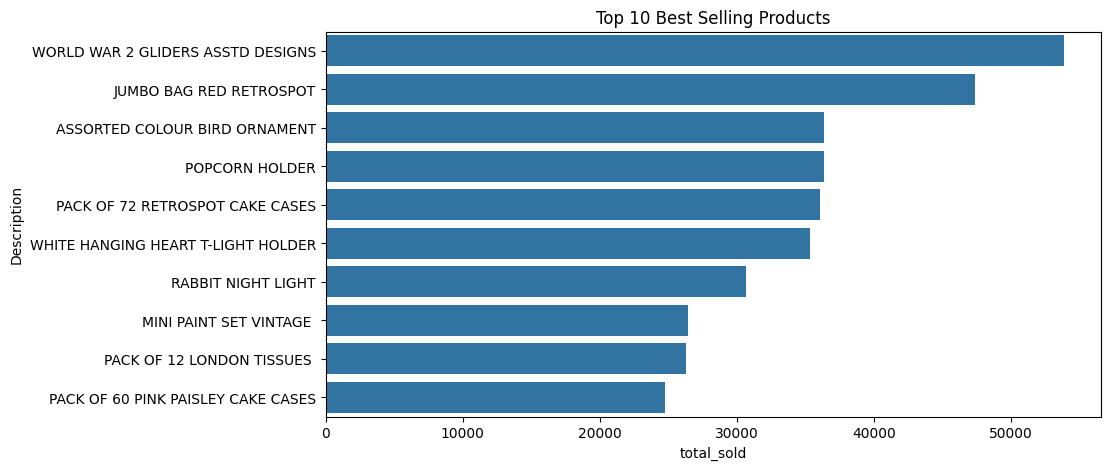

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_products, x="total_sold", y="Description")
plt.title("Top 10 Best Selling Products")
plt.show()

In [11]:
query = """
SELECT
Country,
SUM(Quantity * UnitPrice) AS revenue
FROM online_retail
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10
"""

country_sales = pd.read_sql(query, conn)

country_sales

,Country,revenue
0,United Kingdom,8.187806e+06
1,Netherlands,2.846615e+05
2,EIRE,2.632768e+05
3,Germany,2.216982e+05
4,France,1.974039e+05
5,Australia,1.370773e+05
6,Switzerland,5.638535e+04
7,Spain,5.477458e+04
8,Belgium,4.091096e+04
9,Sweden,3.659591e+04


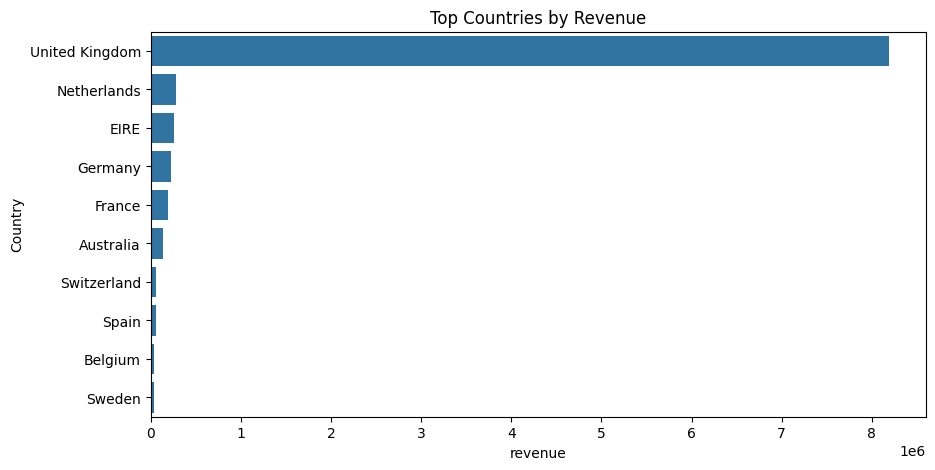

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(data=country_sales, x="revenue", y="Country")
plt.title("Top Countries by Revenue")
plt.show()

Business Insights

1. Monthly Revenue Trend
Sales increased significantly during the final months of the year, indicating strong seasonal demand.

2. Top Selling Products
Decorative household items appear among the top-selling products, suggesting strong demand for gift-related merchandise.

3. Revenue by Country
The United Kingdom contributes the majority of total revenue, while other European countries represent smaller markets.